In [11]:
# =========================
# 0. CARGA DE LIBRERIAS
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [32]:
# =========================
# 1. CARGA DE DATOS
# =========================
df = pd.read_csv("accidentes.csv")

# limpiar texto
df["ProbableCause"] = df["ProbableCause"].fillna("").str.lower()

In [33]:
# =========================
# 2. CLASIFICACIÓN FASE DESPEGUE
# =========================
def clasificar_fase(texto):
    if any(p in texto for p in [
        "runway", "directional control", "swerved", "runway excursion",
        "abort", "during takeoff roll", "collision with"
    ]):
        return "Takeoff Roll"

    elif any(p in texto for p in [
        "initial climb", "after takeoff", "climb",
        "stall", "trees", "rotation", "pitch"
    ]):
        return "Initial Climb"

    else:
        return "Unclassified"

df["Fase"] = df["ProbableCause"].apply(clasificar_fase)

# Daños aeronave

def damage(value):
    if pd.isna(value):
        return None

    # normalizar texto
    value = str(value).lower()

    # separar por coma
    parts = [v.strip() for v in value.split(",")]

    # mapa robusto (por si vienen variantes)
    mapping = {
        "destroyed": "destroyed",
        "substantial": "substantial",
        "minor": "minor"
    }

    # filtrar solo categorías válidas
    valid = [mapping[p] for p in parts if p in mapping]

    if not valid:
        return None

    # jerarquía de severidad
    severity_order = {
        "destroyed": 3,
        "substantial": 2,
        "minor": 1
    }

    # devolver la más severa
    return max(valid, key=lambda x: severity_order[x])

In [34]:
# =========================
# 3. CLASIFICACIÓN CAUSAS
# =========================
def clasificar_causa(texto):

    if any(p in texto for p in ["weight", "performance", "overload"]):
        return "Planificación deficiente"

    elif any(p in texto for p in ["abort", "continue takeoff", "decision"]):
        return "Mala decisión abortaje"

    elif any(p in texto for p in ["loss of control", "directional control", "swerved"]):
        return "Pérdida de control"

    elif any(p in texto for p in ["maintenance", "fuel contamination", "mechanical failure"]):
        return "Falla mecánica"

    elif any(p in texto for p in ["trim", "configuration", "checklist"]):
        return "Configuración incorrecta"

    elif any(p in texto for p in ["pitch", "rotation", "premature"]):
        return "Rotación inadecuada"

    elif any(p in texto for p in ["animal", "bird", "deer"]):
        return "Colisión externa"

    else:
        return "Otros"

df["Causa"] = df["ProbableCause"].apply(clasificar_causa)

In [37]:
# =========================
# 4. VARIABLES DERIVADAS
# =========================

# Nivel de lesión simplificado
df["Injury"] = df["HighestInjuryLevel"].fillna("None")

# Daño aeronave
df["Damage_Clean"] = df["AirCraftDamage"].apply(clean_damage)

# Condición meteorológica
df["Weather"] = df["WeatherCondition"].fillna("Unknown")

In [39]:
# =========================
# 5. ESTADÍSTICAS
# =========================

print("\n=== TOTAL DE ACCIDENTES ===")
print(len(df))

print("\n=== DISTRIBUCIÓN POR FASE ===")
print(df["Fase"].value_counts(normalize=True)*100)

print("\n=== DISTRIBUCIÓN POR CAUSA ===")
print(df["Causa"].value_counts(normalize=True)*100)

print("\n=== LESIONES ===")
print(df["Injury"].value_counts(normalize=True)*100)

print("\n=== DAÑO AERONAVE ===")
damage_counts = df["Damage_Clean"].value_counts(normalize=True) * 100
print(damage_counts)

print("\n=== CONDICIONES METEOROLÓGICAS ===")
print(df["Weather"].value_counts(normalize=True)*100)


=== TOTAL DE ACCIDENTES ===
682

=== DISTRIBUCIÓN POR FASE ===
Fase
Takeoff Roll     60.850440
Unclassified     20.967742
Initial Climb    18.181818
Name: proportion, dtype: float64

=== DISTRIBUCIÓN POR CAUSA ===
Causa
Pérdida de control          33.870968
Otros                       31.085044
Mala decisión abortaje      19.208211
Planificación deficiente     5.718475
Rotación inadecuada          3.812317
Colisión externa             2.932551
Configuración incorrecta     2.346041
Falla mecánica               1.026393
Name: proportion, dtype: float64

=== LESIONES ===
Injury
None       70.527859
Minor      13.636364
Fatal       9.090909
Serious     6.744868
Name: proportion, dtype: float64

=== DAÑO AERONAVE ===
Damage_Clean
substantial    92.815249
destroyed       6.451613
minor           0.733138
Name: proportion, dtype: float64

=== CONDICIONES METEOROLÓGICAS ===
Weather
VMC    99.41349
IMC     0.58651
Name: proportion, dtype: float64


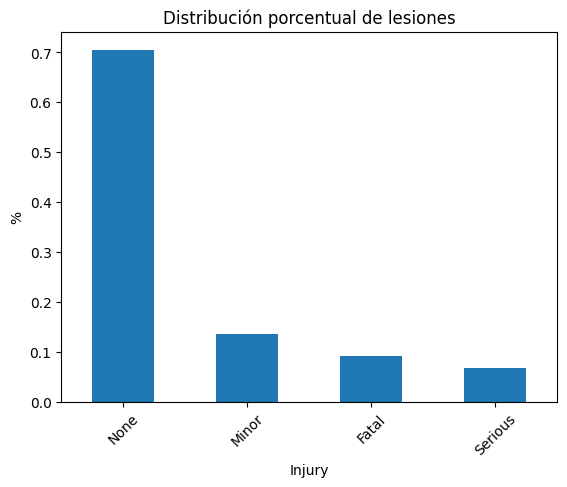

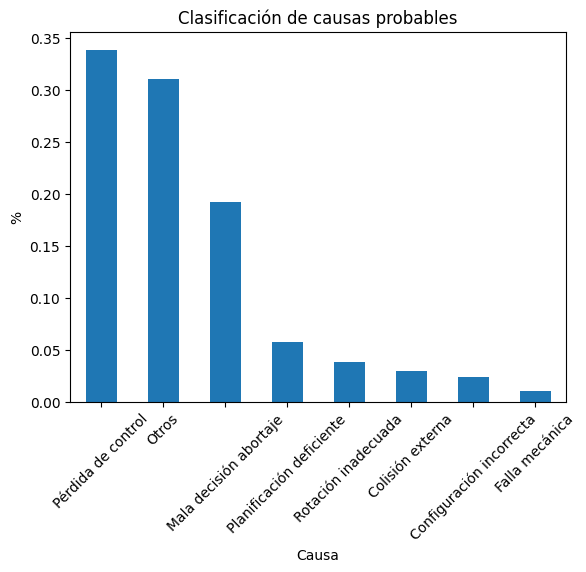

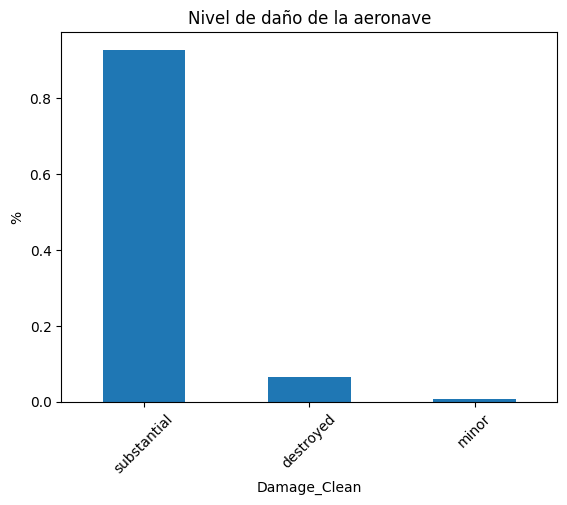

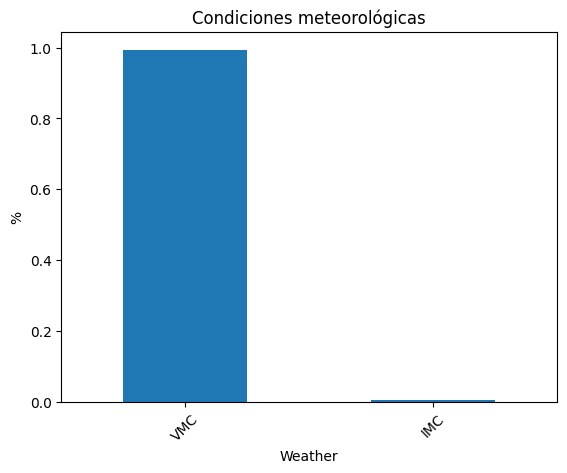

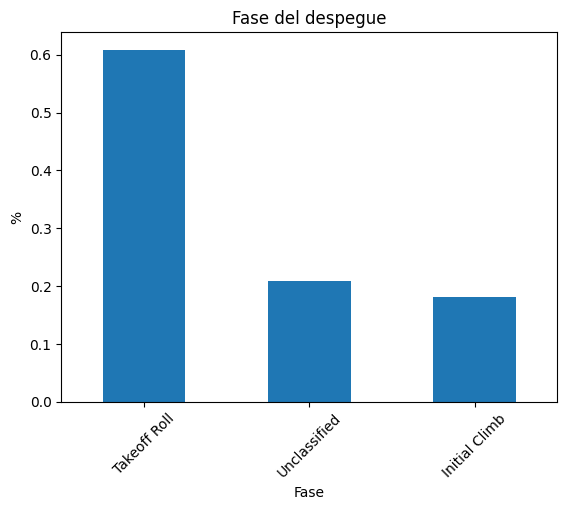

In [41]:
# =========================
# 6. GRÁFICOS
# =========================

plt.rcParams["font.family"] = "DejaVu Sans"

# -------- Lesiones --------
plt.figure()
df["Injury"].value_counts(normalize=True).plot(kind="bar")
plt.title("Distribución porcentual de lesiones")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.show()

# -------- Causas --------
plt.figure()
df["Causa"].value_counts(normalize=True).plot(kind="bar")
plt.title("Clasificación de causas probables")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.show()

# -------- Daño --------
plt.figure()
df["Damage_Clean"].value_counts(normalize=True).plot(kind="bar")
plt.title("Nivel de daño de la aeronave")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.show()

# -------- Clima --------
plt.figure()
df["Weather"].value_counts(normalize=True).plot(kind="bar")
plt.title("Condiciones meteorológicas")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.show()

# -------- Fase --------
plt.figure()
df["Fase"].value_counts(normalize=True).plot(kind="bar")
plt.title("Fase del despegue")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.show()

In [42]:
# =========================
# 7. CRUCES IMPORTANTES
# =========================

# Causa vs Fase
tabla_cruce = pd.crosstab(df["Causa"], df["Fase"], normalize="index") * 100

print("\n=== CAUSA vs FASE (%) ===")
print(tabla_cruce.round(1))

# =========================
# 8. EXPORTAR RESULTADOS
# =========================
df.to_csv("accidentes_clasificados.csv", index=False)


=== CAUSA vs FASE (%) ===
Fase                      Initial Climb  Takeoff Roll  Unclassified
Causa                                                              
Colisión externa                    5.0          75.0          20.0
Configuración incorrecta           31.2          12.5          56.2
Falla mecánica                     14.3          28.6          57.1
Mala decisión abortaje              5.3          85.5           9.2
Otros                              33.0          22.6          44.3
Planificación deficiente           35.9          38.5          25.6
Pérdida de control                  4.8          91.8           3.5
Rotación inadecuada                57.7          34.6           7.7
